Features: (9578, 13)
Target: (9578,)
Categorical: ['purpose']
Numeric: ['credit.policy', 'int.rate', 'installment', 'log.annual.inc', 'dti', 'fico', 'days.with.cr.line', 'revol.bal', 'revol.util', 'inq.last.6mths', 'delinq.2yrs', 'pub.rec']
Training data: (7662, 13)
Testing data: (1916, 13)
Accuracy : 0.654
Precision: 0.2514
Recall   : 0.5863
F1 Score : 0.3519
ROC-AUC  : 0.6771


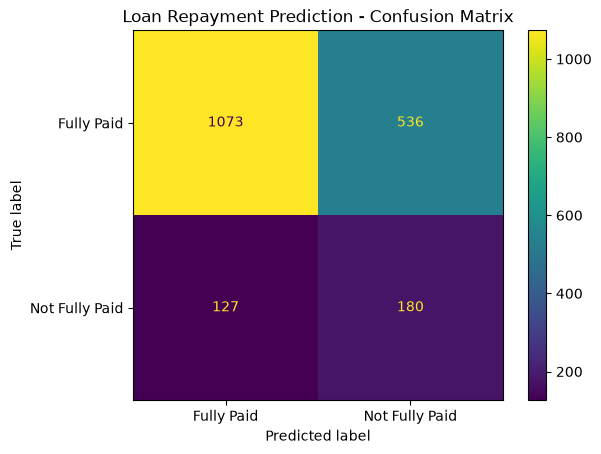

                precision    recall  f1-score   support

    Fully Paid       0.89      0.67      0.76      1609
Not Fully Paid       0.25      0.59      0.35       307

      accuracy                           0.65      1916
     macro avg       0.57      0.63      0.56      1916
  weighted avg       0.79      0.65      0.70      1916

True Negative : 1073
False Positive: 536
False Negative: 127
True Positive : 180
Baseline Accuracy: 0.8398
Logistic Regression Accuracy: 0.654


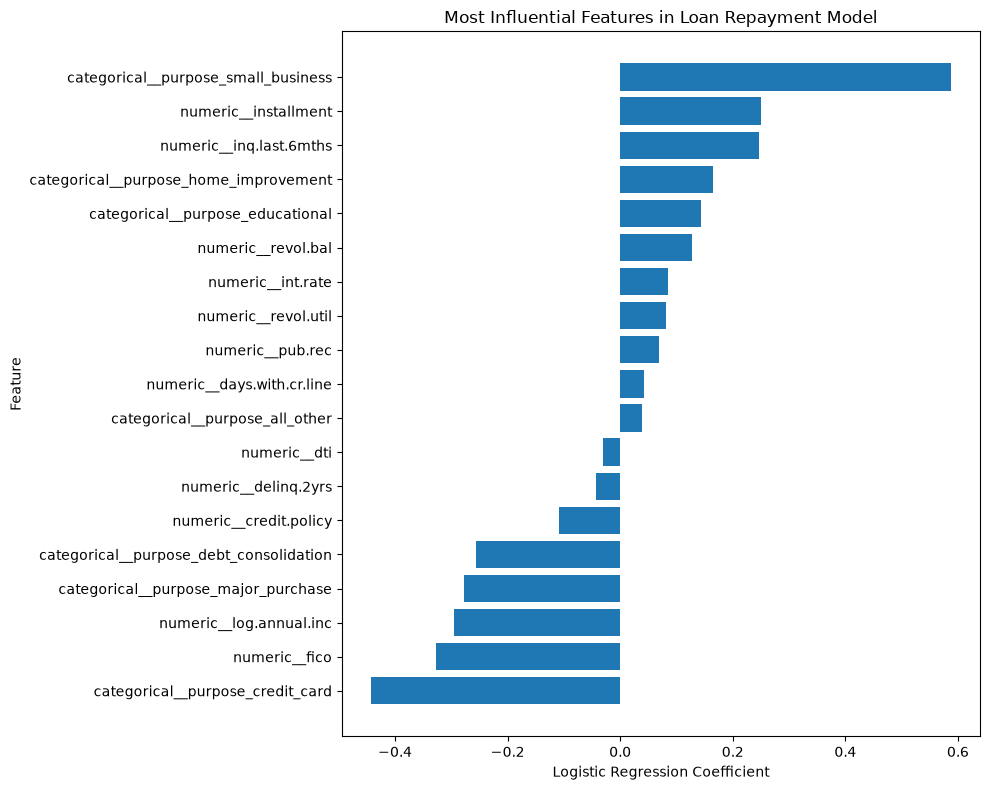

Random Forest
--------------------
Accuracy : 0.8178
Precision: 0.3385
Recall   : 0.1433
F1 Score : 0.2014
ROC-AUC  : 0.6462


In [44]:
import pandas as pd
import numpy as np

df = pd.read_csv("../data/loan_data.csv")

df.head()

df.shape
target = "not.fully.paid"
df["not.fully.paid"].value_counts()
df["not.fully.paid"].value_counts(normalize=True) * 100

X = df.drop("not.fully.paid", axis=1)

y = df["not.fully.paid"]

print("Features:", X.shape)
print("Target:", y.shape)

X.dtypes

categorical_features = ["purpose"]

numeric_features = [col for col in X.columns if col not in categorical_features]

print("Categorical:", categorical_features)
print("Numeric:", numeric_features)

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer

preprocessor = ColumnTransformer(
    transformers=[
        ("numeric", StandardScaler(), numeric_features),
        ("categorical", OneHotEncoder(handle_unknown="ignore"), categorical_features),
    ]
)

from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression

logistic_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", LogisticRegression(max_iter=1000, class_weight="balanced")),
    ]
)

logistic_model.fit(X_train, y_train)

y_pred = logistic_model.predict(X_test)

y_probability = logistic_model.predict_proba(X_test)[:, 1]


from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
)

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_probability)

print("Accuracy :", round(accuracy, 4))
print("Precision:", round(precision, 4))
print("Recall   :", round(recall, 4))
print("F1 Score :", round(f1, 4))
print("ROC-AUC  :", round(roc_auc, 4))

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm, display_labels=["Fully Paid", "Not Fully Paid"]
)

disp.plot()

plt.title("Loan Repayment Prediction - Confusion Matrix")
plt.show()

# ----------

from sklearn.metrics import classification_report

print(
    classification_report(y_test, y_pred, target_names=["Fully Paid", "Not Fully Paid"])
)

cm = confusion_matrix(y_test, y_pred)

print("True Negative :", cm[0, 0])
print("False Positive:", cm[0, 1])
print("False Negative:", cm[1, 0])
print("True Positive :", cm[1, 1])

baseline_predictions = np.zeros(len(y_test))

baseline_accuracy = accuracy_score(y_test, baseline_predictions)

print("Baseline Accuracy:", round(baseline_accuracy, 4))

print("Logistic Regression Accuracy:", round(accuracy, 4))

preprocessor_fitted = logistic_model.named_steps["preprocessor"]

model = logistic_model.named_steps["model"]

feature_names = preprocessor_fitted.get_feature_names_out()

coefficients = model.coef_[0]

feature_importance = pd.DataFrame(
    {"feature": feature_names, "coefficient": coefficients}
)

feature_importance = feature_importance.sort_values("coefficient", ascending=False)

feature_importance

feature_importance.head(10)

feature_importance.tail(10)

top_features = pd.concat([feature_importance.head(10), feature_importance.tail(10)])

top_features = top_features.sort_values("coefficient")

plt.figure(figsize=(10, 8))

plt.barh(top_features["feature"], top_features["coefficient"])

plt.xlabel("Logistic Regression Coefficient")
plt.ylabel("Feature")
plt.title("Most Influential Features in Loan Repayment Model")

plt.tight_layout()
plt.show()

# Train a Second Model

from sklearn.ensemble import RandomForestClassifier

random_forest_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "model",
            RandomForestClassifier(
                n_estimators=200, random_state=42, class_weight="balanced", n_jobs=-1
            ),
        ),
    ]
)

random_forest_model.fit(X_train, y_train)

rf_pred = random_forest_model.predict(X_test)

rf_probability = random_forest_model.predict_proba(X_test)[:, 1]

rf_accuracy = accuracy_score(y_test, rf_pred)
rf_precision = precision_score(y_test, rf_pred)
rf_recall = recall_score(y_test, rf_pred)
rf_f1 = f1_score(y_test, rf_pred)
rf_roc_auc = roc_auc_score(y_test, rf_probability)

print("Random Forest")
print("--------------------")
print("Accuracy :", round(rf_accuracy, 4))
print("Precision:", round(rf_precision, 4))
print("Recall   :", round(rf_recall, 4))
print("F1 Score :", round(rf_f1, 4))
print("ROC-AUC  :", round(rf_roc_auc, 4))

model_comparison = pd.DataFrame(
    {
        "Model": ["Logistic Regression", "Random Forest"],
        "Accuracy": [accuracy, rf_accuracy],
        "Precision": [precision, rf_precision],
        "Recall": [recall, rf_recall],
        "F1 Score": [f1, rf_f1],
        "ROC-AUC": [roc_auc, rf_roc_auc],
    }
)

model_comparison

model_comparison.to_csv("../data/model_comparison.csv", index=False)

feature_importance.to_csv("../data/logistic_feature_importance.csv", index=False)